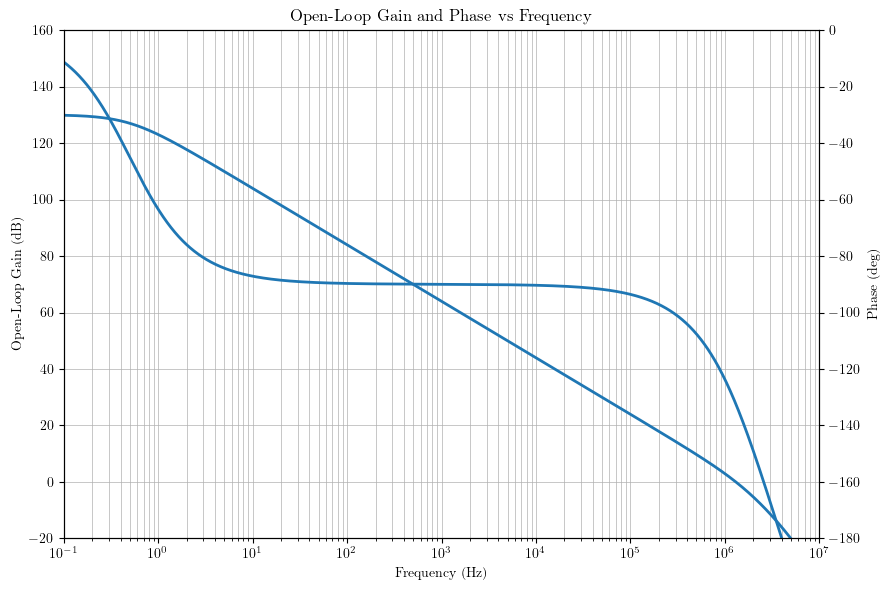

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------
# Transfer function chosen to match the figure
# -------------------------------------------------
# High DC gain (~150 dB)
A0 = 10**(130/20)      # Convert 150 dB to linear gain

# Pole frequencies (Hz) tuned to resemble the image
f1 = 0.5               # dominant pole
f2 = 2e6               # second pole
f3 = 8e6               # third pole

w1 = 2*np.pi*f1
w2 = 2*np.pi*f2
w3 = 2*np.pi*f3

# Transfer function:
#            A0
# H(s) = ------------------
#        (1+s/w1)(1+s/w2)(1+s/w3)

num = [A0]
den = np.polymul([1/w1, 1], np.polymul([1/w2, 1], [1/w3, 1]))

system = signal.TransferFunction(num, den)

# -------------------------------------------------
# Frequency range (0.1 Hz to 10 MHz)
# -------------------------------------------------
f = np.logspace(-1, 7, 2000)
w = 2*np.pi*f

w, mag, phase = signal.bode(system, w)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax1 = plt.subplots(figsize=(9, 6))

# Gain plot
ax1.semilogx(f, mag, linewidth=2)
ax1.set_xlim(1e-1, 1e7)
ax1.set_ylim(-20, 160)
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Open-Loop Gain (dB)")
ax1.grid(which="both", linestyle='-', linewidth=0.5)

# Phase plot (right axis)
ax2 = ax1.twinx()
ax2.semilogx(f, phase, linewidth=2)
ax2.set_ylim(-180, 0)
ax2.set_ylabel("Phase (deg)")

plt.title("Open-Loop Gain and Phase vs Frequency")
plt.tight_layout()
plt.show()


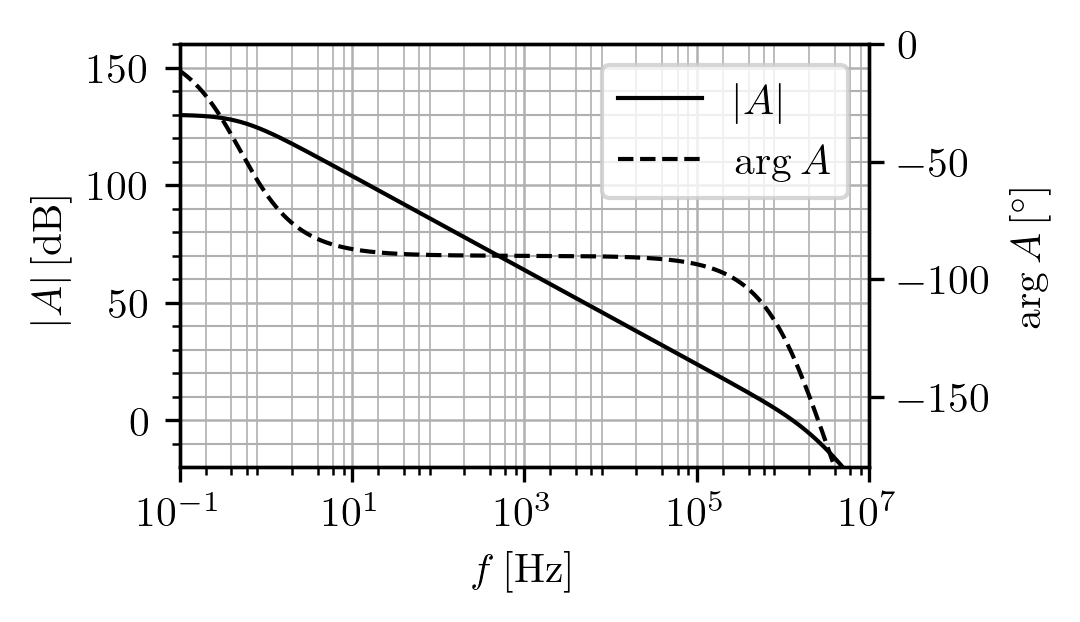

In [77]:
totalW = (6.93 - 1) * 0.5 
fig, ax1 = plt.subplots(figsize=( totalW, totalW/1.618), dpi=300)
ax1.semilogx(f, mag, 'k', linewidth=1, label=r"$|A|$")
ax1.set_xlim(1e-1, 1e7)
ax1.set_ylim(-20, 160)
ax1.set_xlabel(r"$f\rm\,[Hz]$")
ax1.set_ylabel(r"$|A|\rm\,[dB]$")
ax1.grid(which="both", linestyle='-', linewidth=0.5)


# Phase plot (right axis)
ax2 = ax1.twinx()
ax2.semilogx(f, phase, 'k--', linewidth=1, label=r"$\arg A$")

ax1.minorticks_on()

ax2.set_ylim(-180, 0)
ax2.set_ylabel(r"$\arg A\rm\,[^\circ]$")

#ax2.grid()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

from matplotlib.ticker import LogLocator

# Enable minor ticks on log axis
ax1.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)))
ax1.minorticks_on()

from matplotlib.ticker import LogLocator

ax1.set_xscale('log')  # ensure log scale (required)

ax1.xaxis.set_minor_locator(LogLocator(base=10.0,
                                       subs=np.arange(2, 10)[::2] * 0.1,
                                       numticks=100))
ax1.tick_params(axis='x', which='minor', bottom=True)

ax1.grid(True, which='major', axis='both', linewidth=0.6)
ax1.grid(True, which='minor', axis='x', linewidth=0.4)
